# Reproducible Schelling experiments

This notebook studies how preference diversity, mobility limits and destination choice interact to affect segregation and stabilisation in the implemented residential model.

**Default dataset: validated formal social design, 10 seeds per condition, 500-iteration cap.** The social design contains the 270 influence-off controls used for the main analysis and 270 matched influence-on runs. Select one dataset explicitly below and use the validated protocol printed with the results. Missing, partial or incompatible data stop the analysis rather than trigger a fallback. This notebook never launches formal experiments.

The unit of stochastic replication is a **seed**, not a CSV row pooled across fixed conditions. All numerical findings below are computed from validated source data.


## Model and experiment

The finite 40 × 40 grid has 10% vacancies and equally sized A/B populations. Moore neighbourhoods do not wrap. An agent's local similarity is

\[
s_i=\frac{\text{occupied neighbours in the same group}}{\text{occupied neighbours}},
\qquad s_i=0\text{ if it has no occupied neighbours}.
\]

Satisfaction is \(s_i\geq p_i\). The segregation measure \(S=N^{-1}\sum_i s_i\) is mean local same-group similarity, not a universal or chance-adjusted segregation index. Satisfaction rate is the fraction of agents meeting their threshold.

Each sweep shuffles agents and moves them **sequentially**. A dissatisfied agent considers vacancies within Chebyshev radius \(m\). Random chooses any accessible vacancy; improving chooses a random strict improvement; best-fit chooses a highest-scoring vacancy, breaking ties randomly. Best-fit need not improve on the current cell. Destination scores exclude the moving agent's original position.

Optional social influence follows relocation. It updates preferences synchronously using post-movement neighbourhoods and pre-update thresholds:
\(p_i'=p_i+0.1(\bar p_{\mathcal N_i}-p_i)\).
Isolated thresholds remain unchanged; changes at most \(10^{-12}\) are suppressed. No moves and no applied threshold changes indicate stabilisation, which does not require universal satisfaction. Otherwise the run is censored at its configured cap.

Initial preference levels are homogeneous 0.5, low diversity in [0.4, 0.6], and high diversity in [0.2, 0.8]. Shuffled symmetric pairs around 0.5 control the initial mean exactly; draws within a vector are therefore not independent uniform samples. Social influence need not preserve that mean over time.

The main design has 3 diversity levels × 3 radii (1, 3, 5) × 3 strategies × 10 seeds = 270 runs. The social design adds both on/off conditions = 540 runs; its 270 off controls can supply the main analysis without running them twice. Current formal defaults use a cap of 500. The bundled **legacy pilot** has the same 27 main conditions but cap 150. Smoke uses a smaller grid and only tests the workflow.


In [1]:
from pathlib import Path
import hashlib
import json
import statistics
import subprocess
import sys
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
get_ipython().run_line_magic('matplotlib', 'inline')

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if not (ROOT / 'src').is_dir():
    raise RuntimeError('Open this notebook from the project root or notebooks directory.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.analysis_validation import load_dataset
from utils.analysis_statistics import grouped_estimates, paired_effect, condition_summaries

# Explicit protocol selection. Never silently switch to whichever file exists.
DATASET = 'social'       # 'pilot', 'main', 'social', or 'smoke'
MAX_ITERATIONS = 500     # formal main/social: 500; bundled pilot: 150; smoke: 10
DATA_DIR = ROOT / 'data'
SAVE_FIGURES = True
FIGURE_DIR = ROOT / 'notebooks' / 'figures' / f'{DATASET}_{MAX_ITERATIONS}'
BOOTSTRAP_RESAMPLES = 5000
BOOTSTRAP_SEED = 4403


## Validate before analysis

Both summary and history must match the selected protocol: every expected condition and seed exactly once, exact configuration-derived run IDs, finite metrics, correct stopping flags, complete iteration sequences, consistent final measurements and movement/update totals. A 150-step file cannot pass a 500-step protocol check. Validation establishes structural consistency, not proof of scientific correctness or data provenance.

The selected formal social experiment uses `DATASET='social'` and `MAX_ITERATIONS=500`. Its 270 social-influence-off runs provide the main factorial comparisons, while all 540 runs support matched-seed estimates of social-influence effects. This notebook analyses the saved simulation outputs and does not launch simulations.


In [2]:
rows, history_rows, validation = load_dataset(DATA_DIR, DATASET, max_iterations=MAX_ITERATIONS)
main_rows = [row for row in rows if not row['social_influence']]
social_rows = rows if DATASET == 'social' else []
stage = 'Formal configured analysis' if DATASET in ('main', 'social') else 'Exploratory pilot' if DATASET == 'pilot' else 'Workflow smoke test'
print(f'{stage}: {len(rows)} validated runs, {len(history_rows)} history rows.')
print(f"Seeds: {validation['seeds']}; cap: {MAX_ITERATIONS}; main/off controls: {len(main_rows)}.")
if DATASET in ('pilot', 'smoke'):
    print('Smoke/pilot findings do not constitute completed 500-iteration final results.')

# Fingerprint inputs and analysis code without claiming the producing version is known.
stem = {'main': 'main_experiment', 'social': 'social_influence', 'pilot': 'pilot', 'smoke': 'smoke'}[DATASET]
for suffix in ('results', 'history'):
    path = DATA_DIR / f'{stem}_{suffix}.csv'
    print(f'{path.name}: SHA256 {hashlib.sha256(path.read_bytes()).hexdigest()}')
source_files = sorted((ROOT / 'src').glob('*.py')) + sorted((ROOT / 'utils').glob('*.py'))
source_digest = hashlib.sha256()
for path in source_files:
    source_digest.update(path.relative_to(ROOT).as_posix().encode())
    source_digest.update(path.read_bytes())
print('Current source SHA256:', source_digest.hexdigest())
print('Python:', sys.version.split()[0])
print('NumPy:', np.__version__)
import matplotlib
print('Matplotlib:', matplotlib.__version__)
try:
    revision = subprocess.check_output(['git', 'rev-parse', 'HEAD'], cwd=ROOT, text=True).strip()
    dirty = bool(subprocess.check_output(['git', 'status', '--porcelain'], cwd=ROOT, text=True).strip())
    print('Current checkout:', revision, '(uncommitted changes)' if dirty else '(clean)')
except (OSError, subprocess.CalledProcessError):
    print('Git revision unavailable; use the source and CSV fingerprints above.')


Formal configured analysis: 540 validated runs, 184881 history rows.
Seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]; cap: 500; main/off controls: 270.
social_influence_results.csv: SHA256 f5684432bbf425853c993c960723bc634dba1fe858169ab49b27df6dc5533326
social_influence_history.csv: SHA256 caf56c17684534bce056b4400e97840c2e3de699fe03b2ea0706bd70b0875b3b
Current source SHA256: f7bc5a275363ea70781fb2a48900a3a54043b8bb964e2e6d211eac574f9febc2
Python: 3.14.4
NumPy: 2.5.3
Matplotlib: 3.11.2


Current checkout: 328fcbaf11315bd65d2f45c3c291f7eb0d82695a (clean)


## Statistical method

For a marginal comparison, first average the same fixed settings **within each seed**. Then resample the seed-level averages with replacement 5,000 times and report the 2.5th/97.5th percentiles. For the full pilot/main/social designs this retains 10 independent seed blocks, even when a point summarises 90 runs. Fixed-condition estimates use that condition's 10 seed outcomes. The two-seed smoke design only tests the workflow and cannot support research conclusions.

Social effects first match each on/off pair on seed and all remaining recorded configuration fields. We compute on-minus-off, average the 27 fixed-condition differences within each seed, then bootstrap those 10 seed-level effects. Missing/duplicate partners are errors.

These are approximate, pointwise 95% percentile-bootstrap intervals, not simultaneous bounds or a significance test for every plotted comparison. Ten seeds limit precision; resampling does not increase the number of independent observations. A single seed has unavailable uncertainty, not a zero-width error bar. Positive social differences indicate more final local similarity with influence enabled.

Stopping time includes every run. Conditional stabilisation time describes **only the runs that stabilised**, and must be read with the stable/capped counts for the same condition.


In [3]:
def show_figure(fig, name):
    comparison = 'matched social on/off' if name == 'paired_social_effect' else 'social influence off'
    fig.suptitle(f'{stage}: cap {MAX_ITERATIONS}; {comparison}', fontsize=11)
    if SAVE_FIGURES:
        FIGURE_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIGURE_DIR / f'{name}.png', dpi=170, bbox_inches='tight')
    plt.show()
    plt.close(fig)

def estimate_points(ax, estimates, ylabel, title):
    positions = np.arange(len(estimates))
    ax.scatter(positions, [estimate.mean for _, estimate in estimates], color='#225588', zorder=3)
    for position, (_, estimate) in zip(positions, estimates):
        if estimate.lower is not None:
            ax.vlines(position, estimate.lower, estimate.upper, color='#225588')
            ax.hlines([estimate.lower, estimate.upper], position - 0.06, position + 0.06, color='#225588')
    ax.set_xticks(positions, [str(key).replace('_', ' ') for key, _ in estimates])
    ax.set(ylabel=ylabel, title=title)
    ax.grid(axis='y', alpha=0.2)
    for position, (_, estimate) in zip(positions, estimates):
        ax.annotate(f'n={estimate.n_seeds} seeds', (position, 0), xycoords=('data', 'axes fraction'),
                    xytext=(0, 5), textcoords='offset points', ha='center', fontsize=8)

def estimates_by(factor, metric, order, filters=None):
    return grouped_estimates(main_rows, factor, metric, order, filters,
                             resamples=BOOTSTRAP_RESAMPLES, seed=BOOTSTRAP_SEED)

conditions = condition_summaries(main_rows)


## Final local similarity

Each marginal point averages equally over the other fixed factor levels within each seed. Intervals describe variation across seeds. Final means include capped runs and therefore should not all be interpreted as equilibrium segregation.


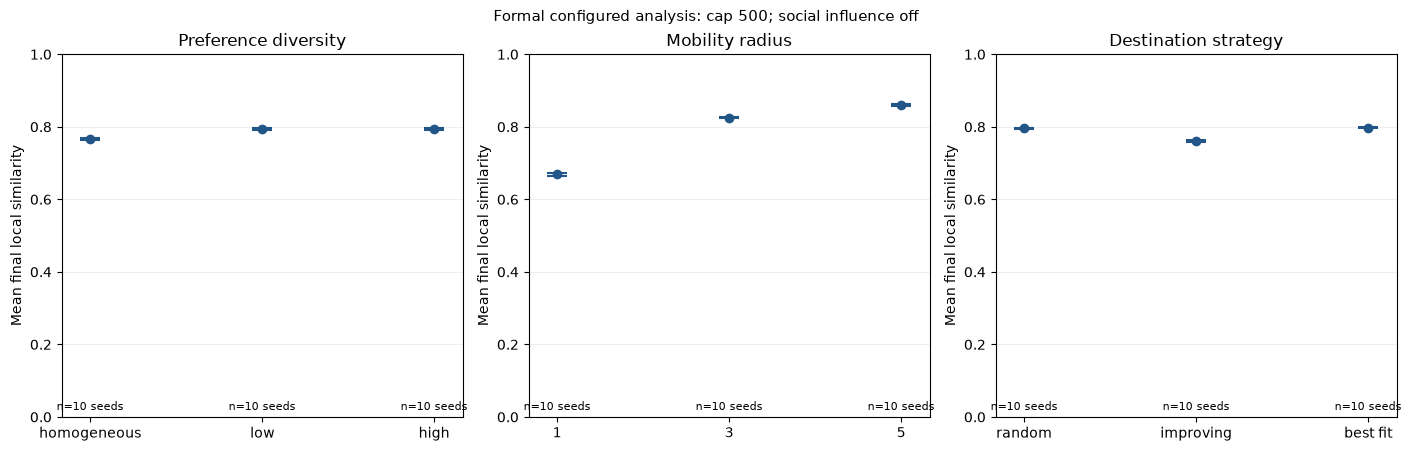

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), constrained_layout=True)
for ax, factor, order, title in zip(
    axes,
    ['preference_diversity', 'mobility', 'behaviour'],
    [['homogeneous', 'low', 'high'], [1, 3, 5], ['random', 'improving', 'best_fit']],
    ['Preference diversity', 'Mobility radius', 'Destination strategy'],
):
    estimate_points(ax, estimates_by(factor, 'final_segregation_index', order),
                    'Mean final local similarity', title)
    ax.set_ylim(0, 1)
fig.suptitle(f'{stage}: cap {MAX_ITERATIONS}; social influence off')
show_figure(fig, 'final_similarity')


## Stopping time and the probability of stabilising

The left panel includes all runs, including those stopped at the cap. The right panel is the fraction stabilised, averaged across fixed settings within each seed. It does not assign the cap as an observed stabilisation time.


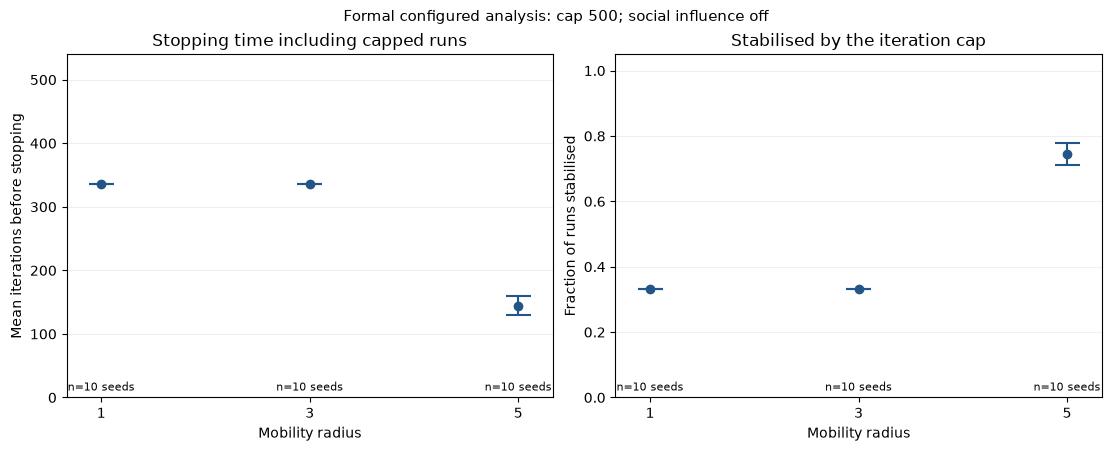

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)
estimate_points(axes[0], estimates_by('mobility', 'iterations', [1, 3, 5]),
                'Mean iterations before stopping', 'Stopping time including capped runs')
axes[0].set_ylim(0, MAX_ITERATIONS * 1.08)
estimate_points(axes[1], estimates_by('mobility', 'stabilised', [1, 3, 5]),
                'Fraction of runs stabilised', 'Stabilised by the iteration cap')
axes[1].set_ylim(0, 1.05)
for ax in axes:
    ax.set_xlabel('Mobility radius')
show_figure(fig, 'stopping_and_stability')


## Stability by complete condition

Each cell displays the number stabilised divided by the number of independent seed runs. Conditions with few stable runs cannot support broad claims about typical stabilisation time. The table below reports mean time **conditional on stabilising**, alongside mean stopping time over all runs.


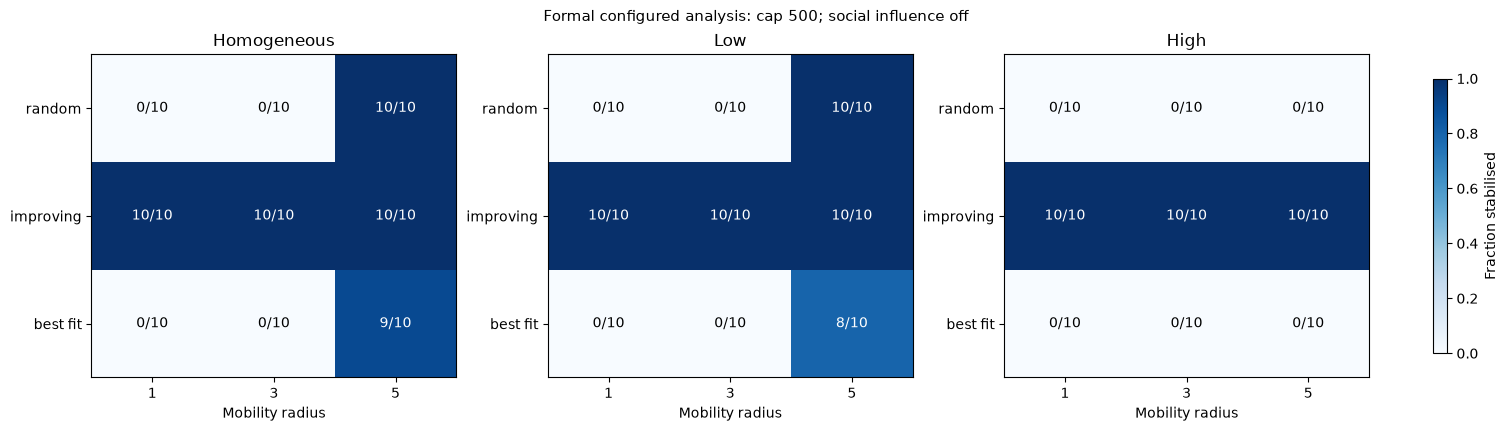

| Diversity | Mobility | Strategy | Stable / runs | Capped | Mean stopping time | Mean time if stable |
|---|---:|---|---:|---:|---:|---:|
| high | 1 | best_fit | 0/10 | 10 | 500.0 | not observed |
| high | 1 | improving | 10/10 | 0 | 9.7 | 9.7 |
| high | 1 | random | 0/10 | 10 | 500.0 | not observed |
| high | 3 | best_fit | 0/10 | 10 | 500.0 | not observed |
| high | 3 | improving | 10/10 | 0 | 10.0 | 10.0 |
| high | 3 | random | 0/10 | 10 | 500.0 | not observed |
| high | 5 | best_fit | 0/10 | 10 | 500.0 | not observed |
| high | 5 | improving | 10/10 | 0 | 9.6 | 9.6 |
| high | 5 | random | 0/10 | 10 | 500.0 | not observed |
| homogeneous | 1 | best_fit | 0/10 | 10 | 500.0 | not observed |
| homogeneous | 1 | improving | 10/10 | 0 | 8.2 | 8.2 |
| homogeneous | 1 | random | 0/10 | 10 | 500.0 | not observed |
| homogeneous | 3 | best_fit | 0/10 | 10 | 500.0 | not observed |
| homogeneous | 3 | improving | 10/10 | 0 | 7.6 | 7.6 |
| homogeneous | 3 | random | 0/10 | 10 | 500.0 | not observed |
| homogeneous | 5 | best_fit | 9/10 | 1 | 58.3 | 9.2 |
| homogeneous | 5 | improving | 10/10 | 0 | 7.6 | 7.6 |
| homogeneous | 5 | random | 10/10 | 0 | 57.3 | 57.3 |
| low | 1 | best_fit | 0/10 | 10 | 500.0 | not observed |
| low | 1 | improving | 10/10 | 0 | 8.7 | 8.7 |
| low | 1 | random | 0/10 | 10 | 500.0 | not observed |
| low | 3 | best_fit | 0/10 | 10 | 500.0 | not observed |
| low | 3 | improving | 10/10 | 0 | 10.1 | 10.1 |
| low | 3 | random | 0/10 | 10 | 500.0 | not observed |
| low | 5 | best_fit | 8/10 | 2 | 107.3 | 9.1 |
| low | 5 | improving | 10/10 | 0 | 10.4 | 10.4 |
| low | 5 | random | 10/10 | 0 | 44.3 | 44.3 |

In [6]:
diversities = list(dict.fromkeys(row['preference_diversity'] for row in main_rows))
behaviours = [name for name in ['random', 'improving', 'best_fit'] if any(row['behaviour'] == name for row in main_rows)]
mobilities = sorted({row['mobility'] for row in main_rows})
lookup = {(row['preference_diversity'], row['mobility'], row['behaviour']): row for row in conditions}
fig, axes = plt.subplots(1, len(diversities), figsize=(5 * len(diversities), 4.2), squeeze=False, constrained_layout=True)
for ax, diversity in zip(axes[0], diversities):
    values = np.array([[lookup[(diversity, mobility, behaviour)]['stabilised_fraction']
                        for mobility in mobilities] for behaviour in behaviours])
    im = ax.imshow(values, vmin=0, vmax=1, cmap='Blues', aspect='auto')
    for i, behaviour in enumerate(behaviours):
        for j, mobility in enumerate(mobilities):
            entry = lookup[(diversity, mobility, behaviour)]
            ax.text(j, i, f"{entry['stable_runs']}/{entry['runs']}", ha='center', va='center',
                    color='white' if values[i, j] > 0.55 else 'black')
    ax.set_xticks(range(len(mobilities)), mobilities)
    ax.set_yticks(range(len(behaviours)), [name.replace('_', ' ') for name in behaviours])
    ax.set(title=diversity.capitalize(), xlabel='Mobility radius')
fig.colorbar(im, ax=list(axes[0]), label='Fraction stabilised', shrink=0.85)
show_figure(fig, 'condition_stability')

table = ['| Diversity | Mobility | Strategy | Stable / runs | Capped | Mean stopping time | Mean time if stable |',
         '|---|---:|---|---:|---:|---:|---:|']
for row in conditions:
    conditional = row['mean_stabilisation_time_if_stable']
    text = 'not observed' if conditional is None else f'{conditional:.1f}'
    table.append(f"| {row['preference_diversity']} | {row['mobility']} | {row['behaviour']} | "
                 f"{row['stable_runs']}/{row['runs']} | {row['capped_runs']} | "
                 f"{row['mean_stopping_time']:.1f} | {text} |")
display(Markdown('\n'.join(table)))


## Interactions between mobility, diversity and strategy

Each point now describes one complete parameter condition across the independent seeds, rather than a marginal average. Shaded bands are pointwise seed-bootstrap intervals. The lines describe how the mobility relationship changes across strategies and diversity levels; visual differences alone are not formal interaction tests.


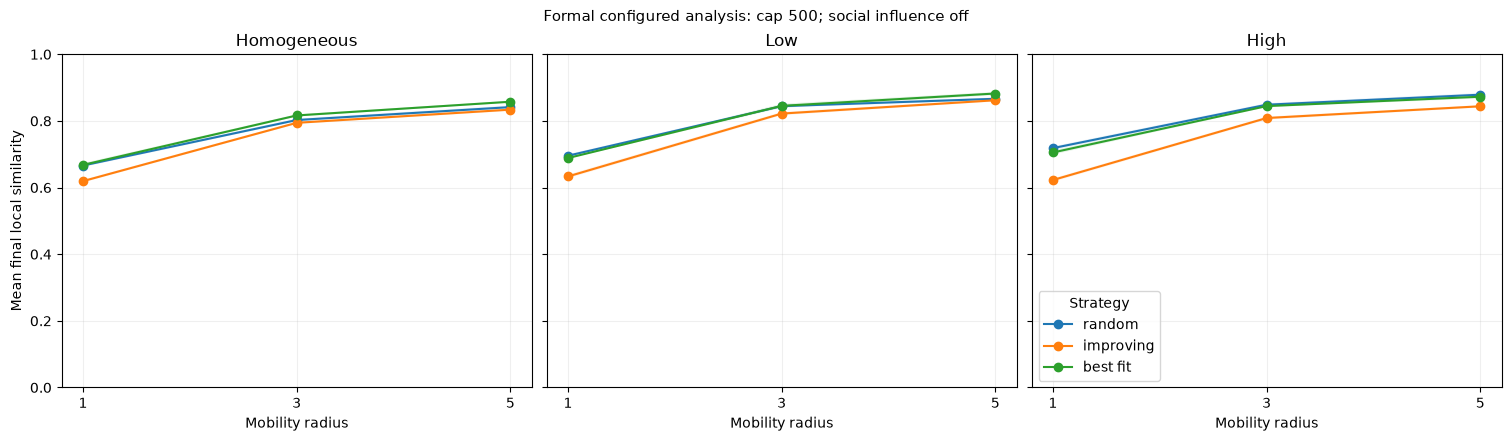

In [7]:
fig, axes = plt.subplots(1, len(diversities), figsize=(5 * len(diversities), 4.3), squeeze=False, sharey=True, constrained_layout=True)
for ax, diversity in zip(axes[0], diversities):
    for behaviour in behaviours:
        results = estimates_by('mobility', 'final_segregation_index', mobilities,
                               {'preference_diversity': diversity, 'behaviour': behaviour})
        x = [key for key, _ in results]
        y = [estimate.mean for _, estimate in results]
        ax.plot(x, y, marker='o', label=behaviour.replace('_', ' '))
        if all(estimate.lower is not None for _, estimate in results):
            ax.fill_between(x, [estimate.lower for _, estimate in results],
                            [estimate.upper for _, estimate in results], alpha=0.12)
    ax.set(title=diversity.capitalize(), xlabel='Mobility radius', ylim=(0, 1))
    ax.set_xticks(mobilities)
    ax.grid(alpha=0.2)
axes[0][0].set_ylabel('Mean final local similarity')
axes[0][-1].legend(title='Strategy')
show_figure(fig, 'factor_interactions')


## Paired social influence effect

This comparison is available only when the explicitly selected complete dataset is `social`. Missing social data are reported as unavailable, never as a zero effect. Smoke includes on/off cases for testing but is not used to make this research comparison.


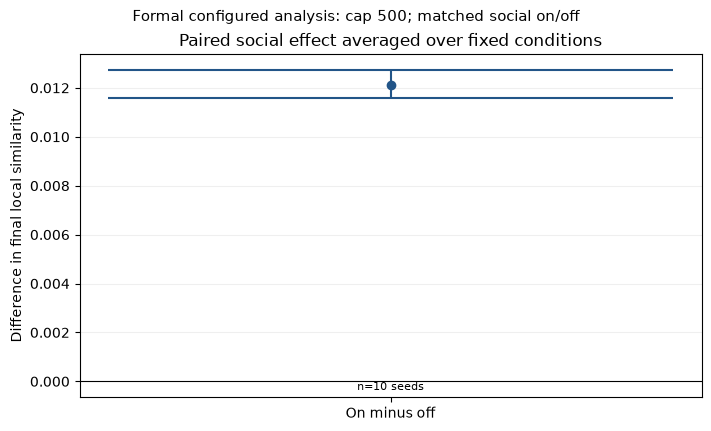

270 matched pairs; 10 independent seed blocks.
Mean on-minus-off: 0.0121; percentile CI: [0.0116, 0.0127].


In [8]:
if DATASET == 'social':
    effect = paired_effect(social_rows, 'final_segregation_index',
                           resamples=BOOTSTRAP_RESAMPLES, seed=BOOTSTRAP_SEED)
    fig, ax = plt.subplots(figsize=(7, 4.2), constrained_layout=True)
    estimate_points(ax, [('On minus off', effect)], 'Difference in final local similarity',
                    'Paired social effect averaged over fixed conditions')
    ax.axhline(0, color='black', linewidth=0.8)
    show_figure(fig, 'paired_social_effect')
    print(f'{effect.n_runs} matched pairs; {effect.n_seeds} independent seed blocks.')
    print(f'Mean on-minus-off: {effect.mean:.4f}; percentile CI: [{effect.lower:.4f}, {effect.upper:.4f}].')
else:
    print('Social influence effect unavailable for this selected dataset. No conclusion about its effect is made.')


## Representative trajectories

The same seed is used for intentionally contrasting configurations. Every legend identifies diversity, strategy, radius and seed. These individual trajectories illustrate dynamics; they do not replace repeated-seed comparisons.


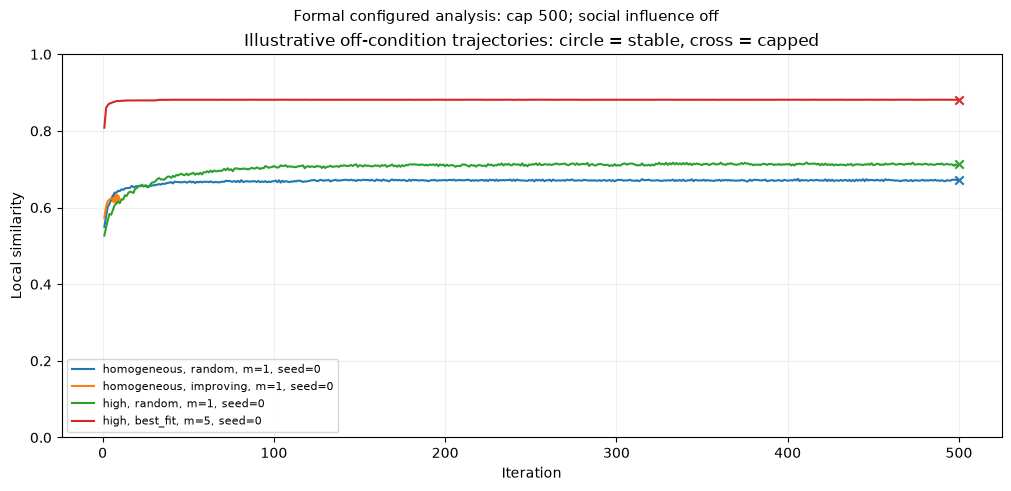

In [9]:
chosen_seed = min(row['seed'] for row in main_rows)
wanted = [('homogeneous', 1, 'random'), ('homogeneous', 1, 'improving'),
          ('high', 1, 'random'), ('high', 5, 'best_fit')]
selected = [row for row in main_rows if row['seed'] == chosen_seed
            and (row['preference_diversity'], row['mobility'], row['behaviour']) in wanted]
by_run = defaultdict(list)
for row in history_rows:
    by_run[row['run_id']].append(row)
fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
for summary in selected:
    values = sorted(by_run[summary['run_id']], key=lambda row: row['iteration'])
    label = f"{summary['preference_diversity']}, {summary['behaviour']}, m={summary['mobility']}, seed={chosen_seed}"
    line, = ax.plot([row['iteration'] for row in values], [row['segregation_index'] for row in values], label=label)
    ax.scatter(values[-1]['iteration'], values[-1]['segregation_index'],
               marker='o' if summary['stabilised'] else 'x', color=line.get_color())
ax.set(xlabel='Iteration', ylabel='Local similarity', title='Illustrative off-condition trajectories: circle = stable, cross = capped', ylim=(0, 1))
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
show_figure(fig, 'representative_trajectories')


## Results and interpretation

The following evidence summary is generated from the selected, validated dataset. It updates when the protocol selector and data change. Pilot findings remain explicitly exploratory.


In [10]:
stable_count = sum(row['stabilised'] for row in main_rows)
low = min(conditions, key=lambda row: row['mean_segregation'])
high = max(conditions, key=lambda row: row['mean_segregation'])
def describe(row):
    return f"{row['preference_diversity']} diversity, m={row['mobility']}, {row['behaviour']}"
display(Markdown(
    f"**{stage}, social influence off.** Across {len(main_rows)} runs, "
    f"{stable_count} ({stable_count / len(main_rows):.1%}) stabilised by the {MAX_ITERATIONS}-iteration cap; "
    f"{len(main_rows) - stable_count} were capped without observed stabilisation. "
    f"Condition-mean final local similarity ranged from **{low['mean_segregation']:.3f}** "
    f"({describe(low)}) to **{high['mean_segregation']:.3f}** ({describe(high)}). "
    "These extrema are descriptive comparisons, not multiplicity-adjusted evidence that the selected conditions are uniquely best or worst."
))
if {1, 5}.issubset(mobilities):
    changes = [lookup[(d, 5, b)]['mean_segregation'] - lookup[(d, 1, b)]['mean_segregation']
               for d in diversities for b in behaviours]
    display(Markdown(
        f"The descriptive change from mobility 1 to 5 ranged from **{min(changes):+.3f}** "
        f"to **{max(changes):+.3f}** across diversity/strategy combinations. "
        "This range should be read with the condition-specific curves and their seed uncertainty, rather than replaced by a single universal mobility claim."
    ))
if DATASET == 'pilot' and MAX_ITERATIONS == 150:
    display(Markdown(
        "**Pilot limitation:** this dataset uses 150 iterations, not the planned 500. "
        "Capped outcomes do not establish eventual equilibrium or a 500-step stabilisation time. "
        "The saved results can guide experiment planning, but must not be presented as the completed final protocol."
    ))


**Formal configured analysis, social influence off.** Across 270 runs, 127 (47.0%) stabilised by the 500-iteration cap; 143 were capped without observed stabilisation. Condition-mean final local similarity ranged from **0.619** (homogeneous diversity, m=1, improving) to **0.882** (low diversity, m=5, best_fit). These extrema are descriptive comparisons, not multiplicity-adjusted evidence that the selected conditions are uniquely best or worst.

The descriptive change from mobility 1 to 5 ranged from **+0.160** to **+0.229** across diversity/strategy combinations. This range should be read with the condition-specific curves and their seed uncertainty, rather than replaced by a single universal mobility claim.

## Discussion

The experiment varies preference dispersion while controlling its initial mean, and varies access to vacancies separately from destination selection. This makes comparisons within the model more interpretable than changing all three mechanisms at once. Marginal averages nevertheless hide differences among particular combinations, so the interaction panels are essential.

The mechanisms offer possible explanations, not additional observations: a larger radius expands the choice set, while improving requires a strict gain and best-fit selects the best available vacancy even if it is worse than the current cell. Continued motion is therefore compatible with the best-fit rule. A frozen state can also contain dissatisfied agents whose permitted moves cannot improve their situation. Whether these explanations account for any particular result should be checked against its trajectory and satisfaction measurements.

Mean same-group neighbour fraction captures local composition on this finite two-group grid. It is not a full measure of residential segregation and has no demographic, housing-cost or real mobility calibration. Fixed boundaries create different neighbour counts at edges. Findings apply to the implemented rules and chosen parameter levels, not directly to real neighbourhood policy.

The full designs use only 10 independent seeds (smoke uses two solely for workflow testing). The bootstrap bands express stochastic uncertainty for fixed tested settings and do not establish precision for untested parameter values. The highest and lowest means are selected from many conditions, so their ranking is descriptive. The on/off experiment, when available, measures the combined consequences of dynamic thresholds under matched initial settings; no social-influence claim can be made from the off-only pilot.

The initial homogeneous-preference conditions serve as internal controls within the same constrained-mobility model. They are not an unrestricted-mobility replication of every classical Schelling formulation. The contribution is the specified factorial comparison of heterogeneous thresholds, limited mobility and destination strategies, with reproducible independent simulation RNGs and explicit treatment of censored runs.


## Conclusion

The validated formal experiment contains 540 runs across 54 conditions, using 10 seeds and a maximum of 500 iterations. Of these runs, 176 stabilised, while 364 reached the iteration cap. Therefore, capped runs represent outcomes observed at the 500-iteration horizon rather than confirmed equilibria.

Final local similarity varied across combinations of preference diversity, mobility radius, and relocation strategy, showing that segregation outcomes depend on interactions between these mechanisms. The matched-seed comparison found that social influence produced a small increase in final local similarity (mean difference = 0.0121, 95% bootstrap CI [0.0116, 0.0127]).

These findings apply to the implemented 40 × 40 model and the tested parameter settings. Future work could use more seeds, longer simulations, alternative segregation measures, and empirically calibrated behavioural assumptions.
